# Q1 Momentum Backtester  
###   *by Dr. W. Vera-Tudela*

## 1. Introduction & Objective

This is a custom backtesting framework built from scratch in Jupyter Notebook with supporting functions in a separate Python file. The framework allows you to test trading strategies against historical market data to evaluate their performance before risking real capital.

Objectives:
- Provide an evidence-based decision-making tool: Test your trading hypotheses with historical data.
- Allow strategy refinement: Identify strengths and weaknesses in your approach.
- Risk management: Understand potential drawdowns and volatility
- Performance comparison: Benchmark your strategy against market indices
- Flexibility: Custom-built framework allows for complete control over testing parameters

This framework provides a solid foundation for quantitative trading strategy development and evaluation.


## 2. Data Pipeline

The structure of the data flow is as follows:

1. Data Management
   - Fetches and cleans real market data from Yahoo Finance
   - Handles historical price data for assets like AAPL and SPY
   - Stores processed data for efficient reuse

2. Signal Generation - moving average crossovers were chosen for their simplicity and interpretability, making them ideal for a baseline strategy."
   - Implements strategy logic, including momentum-based approaches
   - Generates trading signals indexed by days
   - Supports staged entry and exit logic based on rolling averages

3. Backtesting Engine
   - Simulates portfolio evolution with precise cash and position tracking
   - Handles trade execution based on generated signals
   - Manages multiple positions and cash balance throughout the simulation

4. Performance Analysis
   - Measures performance using multiple meaningful metrics:
     - Returns (absolute and relative)
     - Risk-adjusted metrics (Sharpe ratio)
     - Drawdown analysis (maximum drawdown)
     - Trading statistics (win rate)
   - Compares strategy performance against benchmark indices

5. Visualisation
   - Displays equity curves to track portfolio growth
   - Shows drawdown charts to visualise risk periods
   - Provides comparative performance visualisations against benchmarks

This consolidated framework provides a complete pipeline from data acquisition through strategy testing to performance evaluation and visualisation.


## 3. Signal Generation

The first thing to do is to download the historical data for a given time period, then clean it to remove incomplete values and keep only the relevant columns.  
This is done by the function `fetch_data()`.

Subsequently, we calculate the moving average for 20 and 50 days, from which we find the points where MA20 goes over MA50 and vice versa, which are commonly known as the "golden cross" adn "death cross", respectively.  
This is done by the function `add_signals(df)`.

 
## 4. Backtesting Engine
Once the data and signals have been prepared, we move on to the backtesting engine, the core of this notebook.  
Here, we implement two strategies:
1. We hold out our initial capital until the first golden cross appears, and we proceed to buy as many shares as possible. Then we hold it until a death cross shows up, where we sell all of our shares. We repeat this strategy until the end of the time period.
2. We invest all of our capital at the beginning, and we hold it until the end.

This is done by the function `run_backtest()`.
- There is an option for strategy 1 in which we buy in tranches. Namely, investing half of our capital when a golden cross appears, and the other half only if the current price is still above MA20 and MA50 10 days after our buy.


## 5. Performance Metrics
After the backtesting is finished and we have calculated our portfolio value, we calculate the most relevant metrics to compare both strategies with each other and to the S&P500 index.  
We calculate the total returns, Sharpe ratio, maximum drawdown, compounding annual growth rate (CAGR), Calmar ratio, and the win rate as single metrics. In addition, we calculate the yearly returns.  
This is done by the function `compute_metrics()`.


## 6. Results & Analysis
Finally, we show the results in the form of plots and a table for easier visualization.

The main results are shown as a triple plot:
1. The first one shows the equity curve on a daily base, in which we compare the total value of our buy/sell strategy against buying and holding the same asset and buying and holding an index.
   - This is important as it shows how much our total portfolio value grows (or drops) in the same time period under different strategies.
2. The second plot shows the drawdowns on a daily base, where we compare how much our portfolio has dropped in relation to the previous peaks for all three strategies.
    - This is important because it tells us how much our total value fluctuates compared to the other strategies.
3. The last plot shows the annual return, where as opposed to the total return metric, we show the return for each year.
   - This is important as it shows us if our portfolio has had some negative and positive years, which are not visible in the total return.

A table below shows the comparison of the main metrics for all strategies:
- Total Return
- Sharpe
- Max Drawdown
- CAGR
- Calmar
- Win Rate

This is done by the function  `plot_performance()`.


## 7. Conclusions

For this particular scenario with a 10k starting capital over 10 a year period for AAPL under the strategies of buy/sell (without tranching) and buy-hold, compared to the buy-hold of SPY, we can draw the following conclusions:

- What did the strategy achieve?  
  The buy/sell strategy achieves outstanding returns of 327%, outperforming holding SPY with returns of 246%. Nevertheless, buying and holding AAPL for the same period would have resulted in returns of 951%. All this with relatively similar excess return with a fixed risk, Sharpe ratios of 0.53215, 0.4706, and 0.6779, respectively.

- When does it work and when doesn't it?  
  The strategy seems to work best during times of uncertainty and high volatility, like the 2020 crisis. Selling all shares when a death cross appears prevents the portfolio value from dropping too much. As the strategy has a maximum drawdown of -0.2891 compared to the buy-hold value of -0.387297.

- What would you change?  
  If risk and volatility are a concern for the investor, tranching would greatly reduce the maximum drawdown to -0.2265 (vs -0.2891) at the expense of slightly smaller total returns of 310% (vs 327%).

The strategy functions as a bear market defense mechanism. It sacrifices upside participation in sustained bull markets in exchange for reduced drawdown during crises. It is most suitable for risk-averse investor or as a complement to a core buy-and-hold position.

## 8. Limitations & Next Steps

The three most important limitations of this model are the following:  
1. Lookahead bias — we discussed this early on. Are you certain no future information leaked into your signals? In our backtester, it's clean, but it's the first thing anyone will ask.
2. Transaction costs — every buy and sell has a cost. Brokerage fees, bid-ask spread, market impact. We assumed frictionless trading. Over 20 years and dozens of trades, this meaningfully erodes returns.
3. Survivorship bias — we tested on AAPL, MSFT, NVDA. These are companies that survived and thrived. We didn't test on Enron, Lehman Brothers, or Kodak. A strategy that looks great on survivors is lying to you about real-world performance.

Some interesting next steps to go deeper on this project would be:
- Add transaction costs
- Test across 50 stocks
- Look for which asset characteristics make the strategy work best

Just to name few.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns

from Q1_functions import fetch_data, add_signals, run_backtest, compute_metrics, plot_performance

In [2]:
# Load data
starting_capital = 10_000
period = 10
end = pd.Timestamp.today(tz="UTC").normalize()
start = end - pd.DateOffset(years=period)

dataA = fetch_data('AAPL', start, end)
dataA = add_signals(dataA)

dataS = fetch_data('SPY', start, end)
dataS = add_signals(dataS)

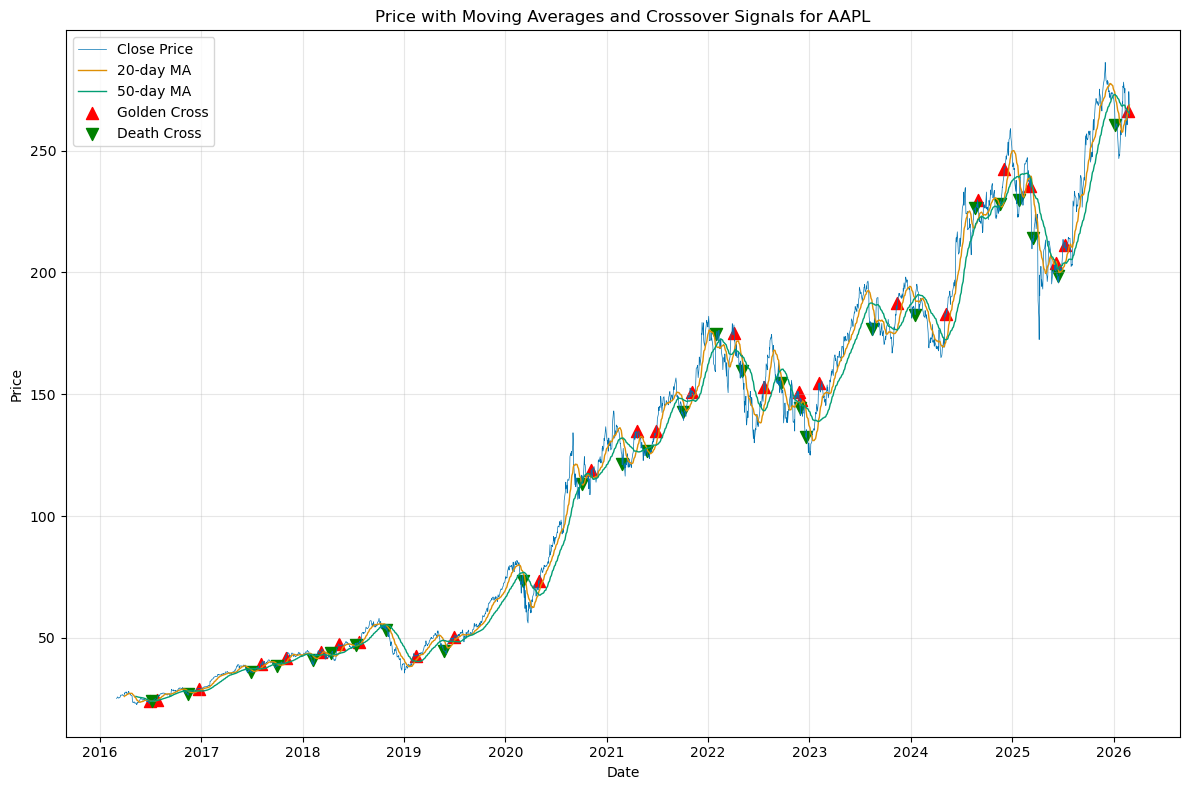

In [3]:
# Visualize the signals to check that the MA and crosses are calöculated correctly
plt.figure(figsize=(12, 8))
colors = sns.color_palette("colorblind")

plt.plot(dataA.index, dataA['Close'], color=colors[0], label='Close Price', linewidth=0.5)
plt.plot(dataA.index, dataA['MA20'], color=colors[1], label='20-day MA', linewidth=1, linestyle='-')
plt.plot(dataA.index, dataA['MA50'], color=colors[2], label='50-day MA', linewidth=1, linestyle='-')

golden_cross_points = dataA[dataA['Golden_Cross']]
death_cross_points = dataA[dataA['Death_Cross']]
plt.scatter(golden_cross_points.index, golden_cross_points['Close'], color='red', s=75, marker='^', label='Golden Cross')
plt.scatter(death_cross_points.index, death_cross_points['Close'], color='green', s=75, marker='v', label='Death Cross')

plt.title('Price with Moving Averages and Crossover Signals for AAPL')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#optional: plottting the buy/sell signals
#plt.figure(figsize=(15, 10))
#colors = sns.color_palette("colorblind")
#plt.subplot(2, 1, 2)
#plt.plot(dataA.index, dataA['Signal'], label='Position (1=Long, 0=Cash)')

#plt.title('Position Based on MA Crossover')
#plt.xlabel('Date')
#plt.ylabel('Signal')
#plt.ylim(-0.1, 1.1)
#plt.grid(True, alpha=0.3)

#plt.tight_layout()
#plt.show()

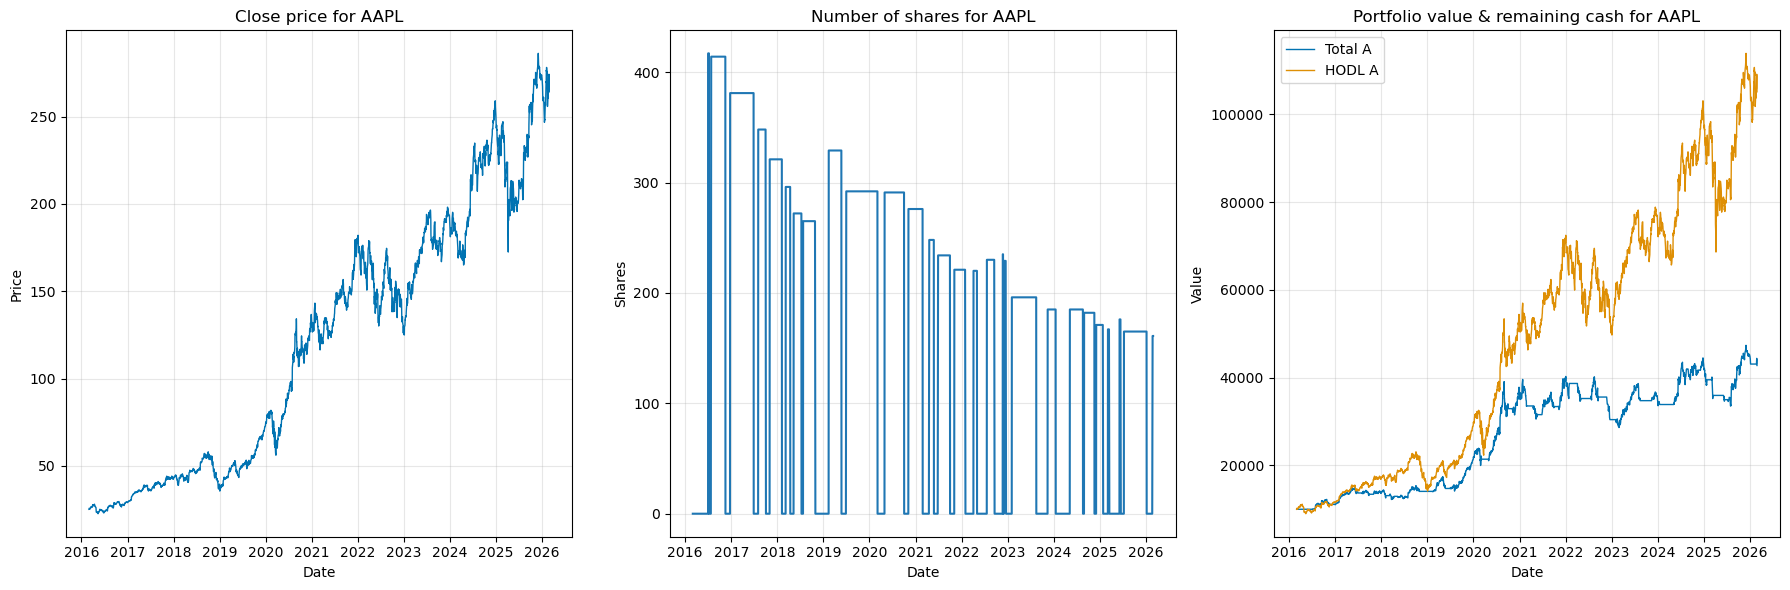

Price,Cash,Portfolio_Value,Shares,Total,Buy_Hold
Date,,,,,
2026-02-23,227.893333,42854.978821,161.0,43082.872154,105910.671803
2026-02-24,227.893333,43814.542358,161.0,44042.435692,108282.111988
2026-02-25,227.893333,44151.031769,161.0,44378.925102,109113.703100
2026-02-26,227.893333,43944.951965,161.0,44172.845299,108604.402873
2026-02-27,227.893333,42532.978821,161.0,42760.872154,105114.889439


In [4]:
dataA = run_backtest(dataA, starting_capital, tranche=False)
dataS = run_backtest(dataS, starting_capital, tranche=False)

plt.figure(figsize=(18, 6))
colors = sns.color_palette("colorblind")

plt.subplot(1, 3, 1)
plt.title('Close price for AAPL')
plt.plot(dataA.index, dataA['Close'], color=colors[0], label='AAPL', linewidth=1)
plt.grid(True, alpha=0.3)
plt.xlabel('Date')
plt.ylabel('Price')

plt.subplot(1, 3, 2)
plt.title('Number of shares for AAPL')
plt.plot(dataA.index, dataA['Shares'], label='Close Price')
plt.grid(True, alpha=0.3)
plt.xlabel('Date')
plt.ylabel('Shares')

plt.subplot(1, 3, 3)
plt.title('Portfolio value & remaining cash for AAPL')
#plt.plot(dataA.index, dataA['Portfolio_Value'], label='Portfolio_Value', alpha=0.5)
#plt.plot(dataA.index, dataA['Cash'], label='Cash', alpha=0.5)
plt.plot(dataA.index, dataA['Total'], color=colors[0], label='Total A', linewidth=1)
plt.plot(dataA.index, dataA['Buy_Hold'], color=colors[1], label='HODL A', linewidth=1)
plt.grid(True, alpha=0.3)
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()

plt.tight_layout()
plt.show()

display(dataA[['Cash', 'Portfolio_Value', 'Shares', 'Total', 'Buy_Hold']].tail())

Last buy still holding.


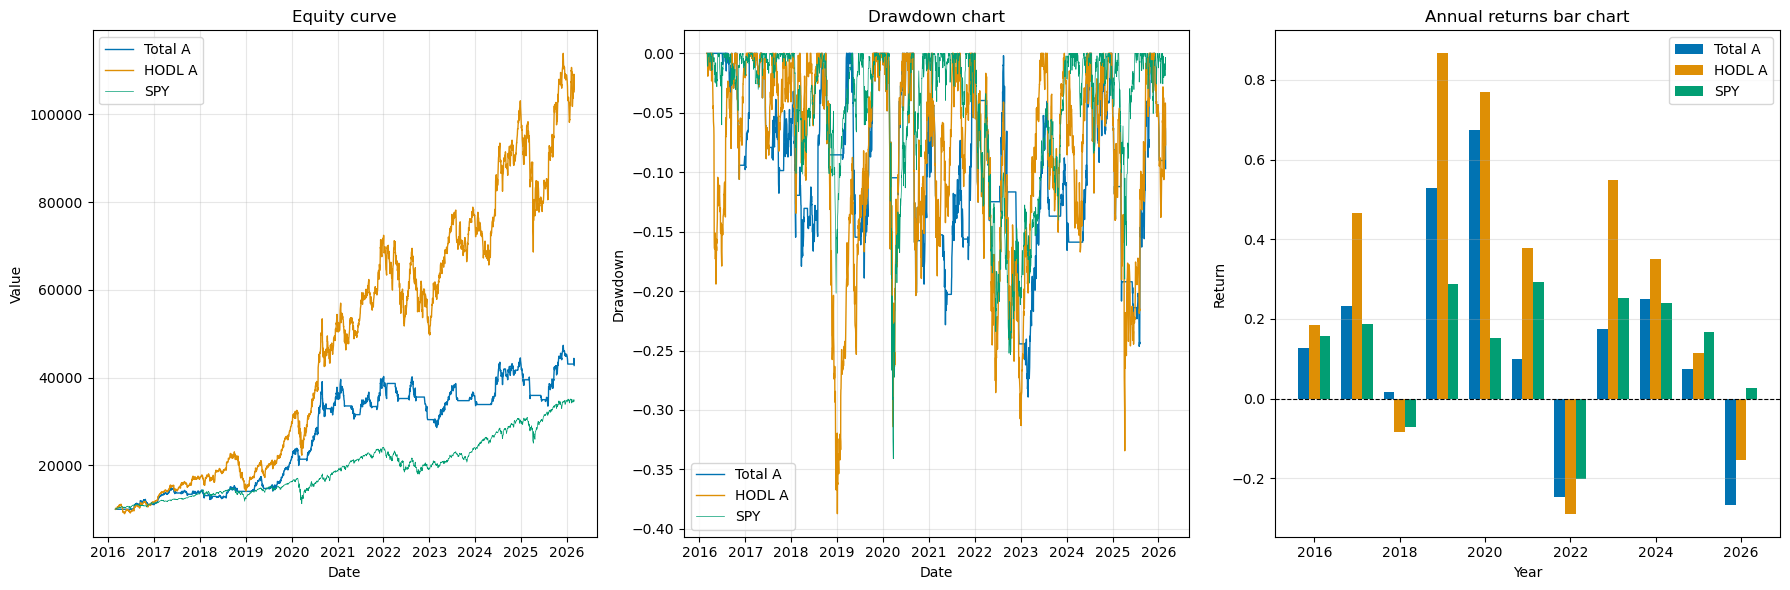

AAPL                 SPY          
              Buy Sell  Buy Hold  Buy Sell  Buy Hold
Total Return  3.276087  9.511489  0.947011  2.462672
Sharpe        0.532157  0.677957  0.236255  0.470650
Max Drawdown -0.289152 -0.387297 -0.292330 -0.341047
CAGR          0.156506  0.265425  0.068948  0.132343
Calmar       -0.541258 -0.685327 -0.235857 -0.388049
Win Rate      0.518519  1.000000  0.636364  1.000000

In [5]:
dataA, tableA, yearly_dataA = compute_metrics(dataA,starting_capital)
dataS, tableS, yearly_dataS = compute_metrics(dataS,starting_capital)

plot_performance(dataA,dataS,yearly_dataA,yearly_dataS)
display(pd.concat([tableA, tableS], axis=1, keys=['AAPL', 'SPY']))

#display(dataA[['Cash', 'Portfolio_Value', 'Shares', 'Total', 'Buy_Hold', 'Drawdown_BS', 'Drawdown_BH']].tail())

#### Plot interpretation

The strategy outperforms in crisis/high volatility years because Death Crosses get you out before the worst of the drawdown. It underperforms in steady bull years because you're sitting in cash during rallies. This is the fundamental character of trend-following: it's a bear market defense mechanism, not a bull market return maximizer. A professional would say this strategy has negative convexity in bull markets and positive convexity in bear markets. Keep that framing — it's how you'd describe it to a portfolio manager.

# Full picture
The strategy earned 40% with a Sharpe of 0.16 and drawdown of -0.29. Buy-and-hold earned 118% with a Sharpe of 0.42 and drawdown of -0.33. The strategy took on nearly as much risk, earned far less, and only marginally reduced your worst loss. On a risk-adjusted basis it's a poor trade.

## This is the honest conclusion a quant would write:
The MA20/50 crossover strategy on AAPL underperforms buy-and-hold on both absolute and risk-adjusted returns over this period. The marginal improvement in max drawdown does not justify the return sacrifice. The strategy may perform better on more volatile assets or in bear markets where capital preservation matters more.

# Main limitations

On limitations — good answers, but you missed the three most important ones from a quant perspective.  
What you said is valid but it's more about testing robustness than structural flaws in the backtester itself. The three a quant interviewer is fishing for are:  
1. Lookahead bias — we discussed this early on. Are you certain no future information leaked into your signals? In our backtester it's clean, but it's the first thing anyone will ask.
2. Transaction costs — every buy and sell has a cost. Brokerage fees, bid-ask spread, market impact. We assumed frictionless trading. Over 20 years and dozens of trades this meaningfully erodes returns.
3. Survivorship bias — we tested on AAPL, MSFT, NVDA. These are companies that survived and thrived. We didn't test on Enron, Lehman Brothers, or Kodak. A strategy that looks great on survivors is lying to you about real-world performance.

These three come up in every serious backtesting conversation. Memorize them.

One specific thing to document that most people skip — write a markdown cell under Results that states your conclusions plainly:

- What did the strategy achieve?
- When does it work and when doesn't it?
- What would you change?